# Curvature Exploration - Synthetic Dataset Only

## !! Today !!

TO-DO
1. Check small graphs w/ different characteristics ie.: channels, number of features, etc.
2. Studiare come si deve il blog per la Ollivier-Ricci, non capisco la parte dell'entropia
3. scatter-plot edge-weights/curvatura
4. perchè i weights sono distribuit in questo modo nel grafo
5. tabella a doppia entrata:
- 3 tipi di struttura ie.: node mean degree, numero di nodi etc
- 3 tipi di features ie.: eterofilia, poi noise?


DONE
- readapt Forman-Weber curvature general function for synthetic dataset and related dictionaries
- Rewrite this notebook for synthetic datasets testing
- modify the Olliver-Ricci curvature computation to test for several $\alpha$ values & limits

## Intuitions

- in a homophilic setting (10% hetero), w/ a low number of classes (2) and low node degree (2), given weights attributed as absolut values of the entries of the sheaf laplacian, close-to-0 weights seem to correlated w/ highly negative curvature
- that seems to be especially true for unnormalized sheaf laplacian entries
-> maybe an eigendecomposition analysis on the curvature matrix might be useful!

## 1. Imports

In [1]:
# be sure to install the required libraries whathever .venv you're using
import sys
from pathlib import Path
import os

print(sys.executable)
os.environ["PATH"] = f"{Path(sys.executable).parent}:{os.environ.get('PATH', '')}"
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install networkx torch torch_sparse matplotlib seaborn
!{sys.executable} -m pip install cmake
!{sys.executable} -m pip install GraphRicciCurvature

/Users/luigifracassetti/projects/neural-sheaf-diffusion/.venv/bin/python


In [2]:
# system
import os
from pathlib import Path

# Avoid duplicate OpenMP runtime crashes when GraphRicciCurvature/NetworKit
# and the scientific Python stack are imported in the same notebook kernel.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# standard data science libraries
import numpy as np
import pandas as pd

# plotting
import seaborn as sns
import networkx as nx

import matplotlib as mpl
from matplotlib import axes
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# core machine learning library
import torch

# utilities
from itertools import product
from typing import Literal, List, Optional

# for Ollivier-Ricci curvature computation
from GraphRicciCurvature.OllivierRicci import OllivierRicci as GraphOllivierRicci
from GraphRicciCurvature.FormanRicci import FormanRicci as GraphFormanRicci

# deprecated option kept for comparison with the previous local implementation
from discrete_geometry_algos.deprecated_imports.ollivier_ricci import OllivierRicci as OllivierRicci_deprecated

## 2. Utilities

### 2.1 Global Variables

In [3]:
# Global variables, for reference
LAYERS = 2
SELECTED_LAYER = 0

EPOCHS = 500
STALK_DIM = 1
DATASET = "synthetic_exp"

HIDDEN_CHANNELS = 16
SYNTHETIC_NODES = 10
SEED = 43
NODE_DEGREE = 4

# Global lists
HET_COEF_LIST = 0.2,
NUM_CLASSES_LIST = 2,
NUM_FEATS_LIST = 15,

# for the Ollivier-Ricci curvature
ALPHA = 0 # must be in [0,1]
ALPHA_ARRAY = .999, # must be in [0,1]

### 2.2 Bash code for dataset generation

In [4]:
# # !! RUN ONLY FOR NEW EXPERIMENTS !!

# # rewriting for bash
# het_coef_list = " ".join(str(_) for _ in HET_COEF_LIST) if type(HET_COEF_LIST) == tuple else str(HET_COEF_LIST)
# num_classes_list = " ".join(str(_) for _ in NUM_CLASSES_LIST) if type(NUM_CLASSES_LIST) == tuple else str(NUM_CLASSES_LIST)
# num_feats_list = " ".join(str(_) for _ in NUM_FEATS_LIST) if type(NUM_FEATS_LIST) == tuple else str(NUM_FEATS_LIST)
# normalization_options = "True False"

# PYTHON_EXEC = sys.executable

# # bash command to run the grid search
# %cd /Users/luigifracassetti/projects/neural-sheaf-diffusion
# !bash ./exp/scripts/grid_launcher.sh \
#     "{PYTHON_EXEC}" \
#     {LAYERS} \
#     {EPOCHS} \
#     {STALK_DIM} \
#     {DATASET} \
#     {HIDDEN_CHANNELS} \
#     {SYNTHETIC_NODES} \
#     {SEED} \
#     {NODE_DEGREE} \
#     "{normalization_options}" \
#     "{het_coef_list}" \
#     "{num_classes_list}" \
#     "{num_feats_list}"

### 2.3 Reference Dataset Dictionary

In [5]:
# basic loop to load the maps and laplacians for each dataset and layer,
# given the same hyper-parameters (layer, heterophilic coefficient, number of classes, number of features)

# data retrieval containers
norm_laplacians, unnorm_laplacians = [], []
var_combinations_dict = {}

# project root (ABSOLUTE PATH)
working_directory = Path("/Users/luigifracassetti/projects/neural-sheaf-diffusion")
# print("Working directory:", working_directory.resolve())

# base results directory
results_root = working_directory / "results" / "laplacians"

# retrieval loop
for layer in range(LAYERS):
    for het_coef in HET_COEF_LIST:
        for num_classes in NUM_CLASSES_LIST:
            for num_feats in NUM_FEATS_LIST:

                combination = (layer, het_coef, num_classes, num_feats)

                var_combinations_dict[combination] = {
                    "norm_laplacian": None,
                    "unnorm_laplacian": None
                }

                filename = (
                    f"DiagSheaf_nodes-{SYNTHETIC_NODES}"
                    f"_node-deg-{NODE_DEGREE}"
                    f"_layer{layer}"
                    f"_pct-hetero-{int(float(het_coef) * 100)}"
                    f"_classes-{num_classes}"
                    f"_feats-{num_feats}"
                    f"_seed{SEED}.pt"
                )

                norm_laplacian_path = (
                    results_root
                    / DATASET
                    / "normalised-true"
                    / f"stalk_dim-{STALK_DIM}"
                    / f"{LAYERS}-layers"
                    / f"{HIDDEN_CHANNELS}-hidden"
                    / f"{EPOCHS}-epochs"
                    / filename
                )

                unnorm_laplacian_path = (
                    results_root
                    / DATASET
                    / "normalised-false"
                    / f"stalk_dim-{STALK_DIM}"
                    / f"{LAYERS}-layers"
                    / f"{HIDDEN_CHANNELS}-hidden"
                    / f"{EPOCHS}-epochs"
                    / filename
                )

                print(f"Norm Laplacian path:\n{norm_laplacian_path}")
                print(f"Unnorm Laplacian path:\n{unnorm_laplacian_path}")
                
                if os.path.exists(norm_laplacian_path) and os.path.exists(unnorm_laplacian_path):
                    norm_laplacian = torch.load(norm_laplacian_path)
                    unnorm_laplacian = torch.load(unnorm_laplacian_path)

                    var_combinations_dict[combination]["norm_laplacian"] = norm_laplacian
                    print(f"Combination: {combination}")
                    print(f"Norm Laplacian shape: {norm_laplacian.shape}")
                    print(f"Norm Laplacian: {norm_laplacian}")
                    
                    var_combinations_dict[combination]["unnorm_laplacian"] = unnorm_laplacian
                    print(f"Combination: {combination}")
                    print(f"Unnorm Laplacian shape: {unnorm_laplacian.shape}")
                    print(f"Unnorm Laplacian: {unnorm_laplacian}")
                else:
                    print(f"Missing files for combination: {combination}")
                    continue

                norm_laplacian_df = pd.DataFrame(var_combinations_dict[combination]["norm_laplacian"].cpu().tolist())
                var_combinations_dict[combination]["norm_laplacians_dataframe"] = norm_laplacian_df
                print(f"norm laplacian df: {norm_laplacian_df}")
                
                unnorm_laplacian_df = pd.DataFrame(var_combinations_dict[combination]["unnorm_laplacian"].cpu().tolist())
                var_combinations_dict[combination]["unnorm_laplacians_dataframe"] = unnorm_laplacian_df
                print(f"unnorm laplacian df: {unnorm_laplacian_df}")

                # normalized final l0
                df_norm = norm_laplacian_df.transpose().copy()
                df_norm.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
                df_norm_new = df_norm.pivot(index="source", columns="target", values="value").fillna(0)
                l0_norm = df_norm_new.to_numpy()
                var_combinations_dict[combination]["l0_norm"] = l0_norm
                print(f"final normalized laplacian: {l0_norm}")
                print(f"shape: {l0_norm.shape}")
                
                # unnormalized final l0
                df_unnorm = unnorm_laplacian_df.transpose().copy()
                df_unnorm.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
                df_unnorm_new = df_unnorm.pivot(index="source", columns="target", values="value").fillna(0)
                l0_unnorm = df_unnorm_new.to_numpy()
                var_combinations_dict[combination]["l0_unnorm"] = l0_unnorm
                print(f"final unnormalized laplacian: {l0_unnorm}")
                print(f"shape: {l0_unnorm.shape}")

Norm Laplacian path:
/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/synthetic_exp/normalised-true/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_nodes-10_node-deg-4_layer0_pct-hetero-20_classes-2_feats-15_seed43.pt
Unnorm Laplacian path:
/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/synthetic_exp/normalised-false/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_nodes-10_node-deg-4_layer0_pct-hetero-20_classes-2_feats-15_seed43.pt
Combination: (0, 0.2, 2, 15)
Norm Laplacian shape: torch.Size([3, 36])
Norm Laplacian: tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,
          1.0000e+00,  2.0000e+00,  2.0000e+00,  3.0000e+00,  3.0000e+00,
          4.0000e+00,  5.0000e+00,  6.0000e+00,  3.0000e+00,  4.0000e+00,
          5.0000e+00,  6.0000e+00,  7.0000e+00,  8.0000e+00,  8.0000e+00,
          9.0000e+00,  6.0000e+00,  9.0000e+00,  9.0000e+00,  9.0000e+00,
          9.0000e+00,  0.0000e+00,  1.0000e+

In [6]:
# toy display
# for key, value in var_combinations_dict.items():
#     print(f"Combination: {key} \n Content: {value}")

### 2.3 Functions

In [7]:
# quick graph plotting function
def plot_curvature_graph(
        weights_dict: dict,
        selected_row: int,
        selected_column: int,
        label: Optional[str]) -> None:

    """
    Plot a graph given an edge weights dictionary,
    with edges colored according to the weights and a colorbar indicating the weight values.
    
    Inputs:
    - weights_dict: dictionary with edge (input, output)-tuple keys and weight values
    - selected_row: int, the row index of the subplot to plot on
    - selected_column: int, the column index of the subplot to plot on
    - label: str, the label for the colorbar

    Assumes a global figure and axes array are defined,
    and that the axes array has enough rows and columns to accommodate the selected_row and selected_column indices.
    """

    G = nx.Graph()
    G.add_edges_from(weights_dict.keys())

    pos = nx.kamada_kawai_layout(G)
    edges = list(sorted(G.edges()))
    weights = np.tanh(np.array([weights_dict[tuple(sorted((u, v)))]for u, v in edges]))
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    nx.draw_networkx_nodes(
        G, pos,
        node_color="black",
        node_size=1,
        alpha=0.5,
        ax=axes[selected_row, selected_column]
    )

    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges,
        edge_color=weights,
        edge_cmap=plt.cm.coolwarm,
        edge_vmin=-1,
        edge_vmax=1,
        width=2.5,
        alpha=0.95,
        ax=axes[selected_row, selected_column]
    )

    sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
    sm.set_array([])

    fig.colorbar(sm, ax=axes[selected_row, selected_column], fraction=0.046, label=label if label is not None else "")
    axes[selected_row, selected_column].axis("off")

In [8]:
# updated function for edge weights and curvatures, takes into account different dataframes selections
def forman_weber_curvature_and_weights(
        L: Literal["norm_Laplacian", "unnorm_Laplacian"] = "norm_Laplacian",
        parameters_combination: tuple = (0, HET_COEF_LIST[0], NUM_CLASSES_LIST[0], NUM_FEATS_LIST[0]),
        node_weight_mode: Literal[
            "units",
            "standard_nodes_degrees", "standard_nodes_degrees_inverted",
            "standard_nodes_degrees_augmented", "standard_nodes_degrees_augmented_inverted",
            "sheaf_nodes_degrees", "sheaf_nodes_degrees_inverted",
            "sheaf_nodes_degrees_augmented", "sheaf_nodes_degrees_augmented_inverted"
            ] = "units",
        output_weights_mode: bool = False):
    
    """
    Compute the Forman-Weber curvature for a given Laplacian and incidence matrix.
    Inputs:
    - L: Literal["norm_Laplacian", "unnorm_Laplacian"], whether to use the normalized or unnormalized 0-Laplacian (default: "norm_Laplacian")
    - dataset: str, the dataset to consider for curvature computation (default: "synthetic_exp")
    - layer_selection: int, the layer to consider for curvature computation (default: 0)
    - node_weight_mode: the mode for computing node weights (default: "units")
    - output_weights_mode: whether to output just the computed node and edge weights along with the starting Laplacian (default: False)

    Outputs:

    if output_weights_mode is True (default):
    - L_0: the selected Laplacian matrix
    - edge_weights_dict: dictionary w/ edge (input, output)-tuple keys, edge weight values
    - node_weights: the computed node weights
    - edge_weights: the computed edge weights

    else:
    - L_0: the selected Laplacian matrix
    - curvature_dict: dictionary w/ edge (input, output)-tuple keys, curvature values
    - node_weights: the computed node weights
    - edge_weights: the computed edge weights
    """
    
    if L == "norm_Laplacian":
        L_0 = var_combinations_dict[parameters_combination]["l0_norm"]

    elif L == "unnorm_Laplacian":
        L_0 = var_combinations_dict[parameters_combination]["l0_unnorm"]

    else:
        raise ValueError(f"Invalid L value: {L}. Expected one of 'norm_Laplacian', 'unnorm_Laplacian'.")
        
    # 1. edge-weights
    edge_weights = np.abs(L_0)

    # 2. node-weights
    if node_weight_mode == "units":
        node_weights = np.ones(L_0.shape[0])

    elif node_weight_mode == "standard_nodes_degrees":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        node_weights = np.diag(D)

    elif node_weight_mode == "standard_nodes_degrees_inverted":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        node_weights = np.diag(np.linalg.inv(D))

    elif node_weight_mode == "standard_nodes_degrees_augmented":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        node_weights = np.diag(D)

    elif node_weight_mode == "standard_nodes_degrees_augmented_inverted":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        node_weights = np.diag(np.linalg.inv(D))

    elif node_weight_mode == "sheaf_nodes_degrees":
        D = np.diag(L_0)
        node_weights = np.diag(D)

    elif node_weight_mode == "sheaf_nodes_degrees_inverted":
        D = np.diag(np.diag(L_0))
        display(D.shape)
        node_weights = np.diag(np.linalg.inv(D))
    
    elif node_weight_mode == "sheaf_nodes_degrees_augmented":
        D = np.diag(L_0)
        display(D.shape)
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        display(D.shape)
        node_weights = np.diag(D)
    
    elif node_weight_mode == "sheaf_nodes_degrees_augmented_inverted":
        D = np.diag(L_0)
        display(D.shape)
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        display(D.shape)

        node_weights = np.diag(np.linalg.inv(D))

    else:
        raise ValueError(f"Invalid node_weight_mode value: {node_weight_mode}")

    if output_weights_mode:
        
        edge_weights_dict = {(i, j): edge_weights[i, j] for i in range(L_0.shape[0]) for j in range(L_0.shape[1]) if (i != j and L_0[i, j] != 0) and (i < j)}
        
        return L_0, dict(sorted(edge_weights_dict.items())), node_weights, edge_weights
    
    else:
        # 3. curvature computation
        curvature_dict = {}
        for i in range(L_0.shape[0]):
            for j in range(L_0.shape[1]):
                if (i != j and L_0[i, j] != 0) and (i < j):
                    edge_key = (i, j)

                    # first term: weight(i) / weight(i,j)
                    term1 = node_weights[i] / edge_weights[i, j]

                    # second term: weight(j) / weight(i,j)
                    term2 = node_weights[j] / edge_weights[i, j]

                    # third term: sum_{over edges k incident to i} of weight of i / sqrt(weight(i,j) * weight(i,k))
                    term3 = 0
                    for k in range(L_0.shape[1]):
                        if k != j and L_0[i,k] != 0:
                            if i < k:
                                term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[i, k])
                            elif i > k:
                                term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[k, i])
                    
                    # fourth term: sum_{over edges k incident to j} of weight of j / sqrt(weight(i,j) * weight(j,k))
                    term4 = 0
                    for k in range(L_0.shape[1]):
                        if k != i and L_0[j,k] != 0:
                            if j < k:
                                term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[j, k])
                            elif j > k:
                                term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[k, j])

                    # summing up the terms and multiplying by the edge weight
                    # curvature_dict[edge_key] = (term1 + term2 - term3 - term4)
                    curvature_dict[edge_key] = edge_weights[i, j] * (term1 + term2 - term3 - term4)
        
        return L_0, dict(sorted(curvature_dict.items())), node_weights, edge_weights

In [9]:
# clean graph cleaning
def clean_graph(G):
    G = nx.convert_node_labels_to_integers(G)
    G = nx.Graph(G)              # force simple undirected graph
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

In [10]:
# alternative graph plotting
def plot_curvature_result(G, curvature_dict, title=None, layout_seed=SEED):
    G = nx.convert_node_labels_to_integers(G)
    pos = nx.spring_layout(G, seed=layout_seed)

    edges = list(G.edges())
    edge_curvatures = [
        np.tanh(curvature_dict.get(tuple(sorted((u, v))), 0.0))
        for u, v in edges
    ]

    vmin = -1
    vmax = 1
    
    fig, ax = plt.subplots(figsize=(7, 4))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=8,
        node_color="black",
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edges,
        edge_color=edge_curvatures,
        edge_cmap=plt.cm.coolwarm,
        edge_vmin=vmin,
        edge_vmax=vmax,
        width=1.5,
        ax=ax,
    )

    ax.set_title(title or "Ollivier-Ricci curvature")
    ax.axis("off")

    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.coolwarm,
        norm=plt.Normalize(vmin=vmin, vmax=vmax),
    )
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Curvature")

    plt.show()

## 3. Weights visuals given different parameters combinations

Issues w/ the current Ollivier-Ricci implementation:

Solved issues:
1. $k(x,y)$ is currently just $k_{\alpha}(x,y)$, to make it a proper Ollivier-Ricci we gotta take the limit $\alpha \to 1$ for $\frac{k_{\alpha}}{1-\alpha}$ -> DONE
2. !!order the edge-weights dictionary BEFORE sorting the list of keys!! -> DONE
3. Lazy random walk $\mu_{x}$ is defined using degree-weighting, instead of proper weights. That's fine, as the OR paper allows an arbitrary bijective $\gamma: \R^{+} \to \R^{+}$, yet it would be interesting to use the identity $id: w_{ij} \to w_{ij}$

[DEBUG] FloydWarshall.weights: shape=(13,), dtype=torch.float64, device=cpu
tensor([0.1262, 0.0995, 0.0036, 0.1310, 0.1496, 0.0916, 0.0722, 0.0830, 0.0163,
        0.0118, 0.1368, 0.0705, 0.0079], dtype=torch.float64)
[DEBUG] OllivierRicci.adjacency: shape=(10, 10), dtype=torch.float32, device=cpu
tensor([[0., 0., 0., 1., 1., 1., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [1., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.]])
[DEBUG] OllivierRicci.weighted_adjacency: shape=(10, 10), dtype=torch.float64, device=cpu
tensor([[0.0000, 0.0000, 0.0000, 0.1262, 0.0995, 0.0036, 0.1310, 0.0000, 0.0000,
         0.0000],
        [0.

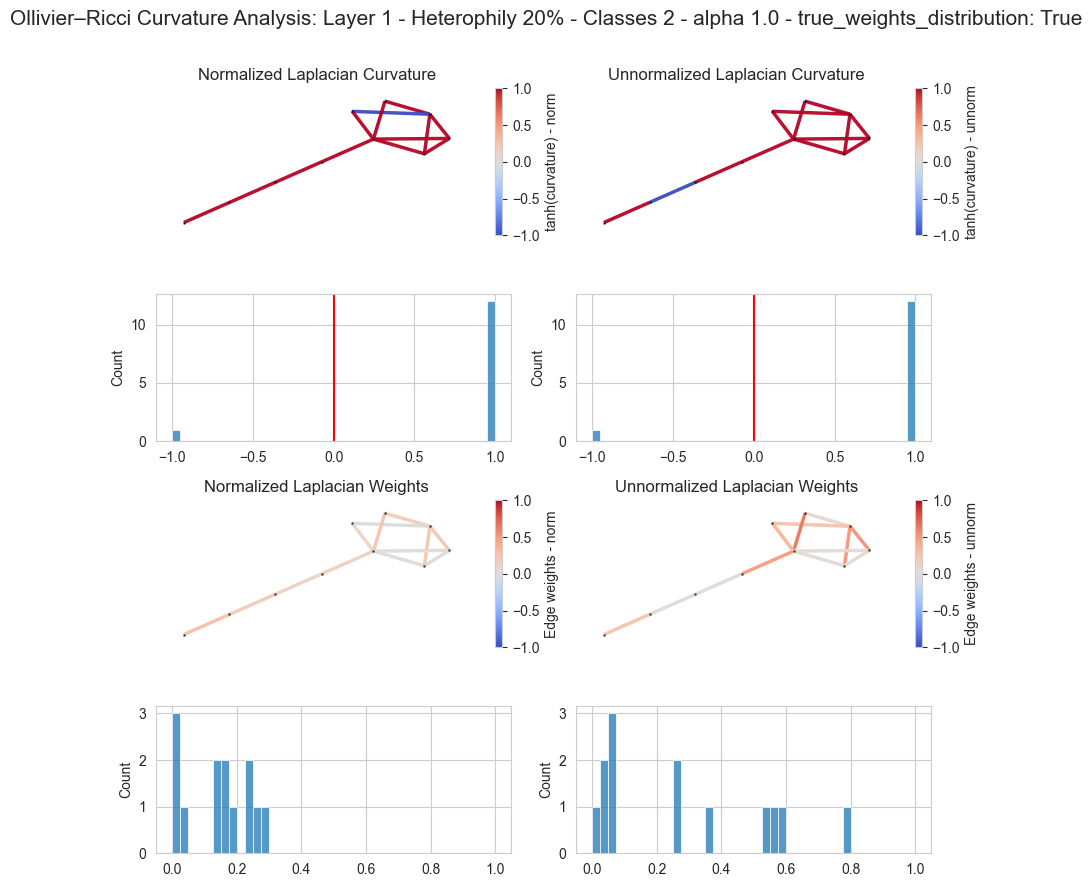

[DEBUG] FloydWarshall.weights: shape=(13,), dtype=torch.float64, device=cpu
tensor([0.0759, 0.0112, 0.0101, 0.0887, 0.1276, 0.1161, 0.1151, 0.0859, 0.0086,
        0.0797, 0.1018, 0.1036, 0.0757], dtype=torch.float64)
[DEBUG] OllivierRicci.adjacency: shape=(10, 10), dtype=torch.float32, device=cpu
tensor([[0., 0., 0., 1., 1., 1., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [1., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.]])
[DEBUG] OllivierRicci.weighted_adjacency: shape=(10, 10), dtype=torch.float64, device=cpu
tensor([[0.0000, 0.0000, 0.0000, 0.0759, 0.0112, 0.0101, 0.0887, 0.0000, 0.0000,
         0.0000],
        [0.

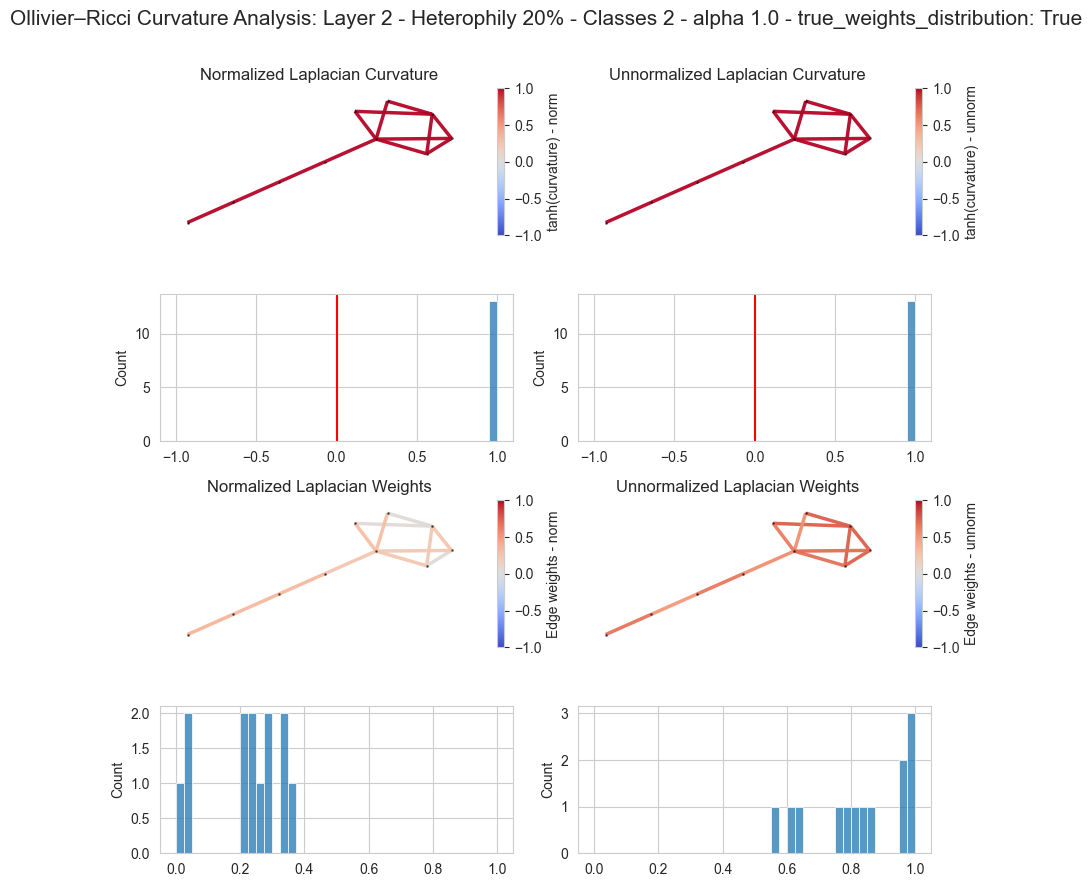

In [11]:
# plotting, for each dataset, the curvature values, subdividing:
# - by layer
# - by heterophily coefficient
# - by number of classes
# - by number of features
# - by Laplacian selection (normalized vs unnormalized)
for combination in var_combinations_dict.keys():
    for alpha in ALPHA_ARRAY:
        for true_weights_distribution in True, :
            layer, het_coef, num_classes, num_feats = combination

            norm_edge_weights_dict = forman_weber_curvature_and_weights(L="norm_Laplacian", parameters_combination=combination, node_weight_mode="units", output_weights_mode=True)[1]
            unnorm_edge_weights_dict = forman_weber_curvature_and_weights(L="unnorm_Laplacian", parameters_combination=combination, node_weight_mode="units", output_weights_mode=True)[1]

            norm_edge_index = sorted(list(norm_edge_weights_dict.keys()))
            norm_edge_weights = torch.tensor(list(norm_edge_weights_dict.values()))

            unnorm_edge_index = sorted(list(unnorm_edge_weights_dict.keys()))
            unnorm_edge_weights = torch.tensor(list(unnorm_edge_weights_dict.values()))

            ollivier_ricci_norm = OllivierRicci_deprecated(
                edge_index=norm_edge_index,
                weights=norm_edge_weights,
                epsilon=0.025,
                rc=None,
                alpha=alpha,
                limit_ricci=True,
                nodes_num=SYNTHETIC_NODES,
                true_weights_distribution=true_weights_distribution,
                true_weights_distance=False,
                debug=True
            )

            ollivier_ricci_unnorm = OllivierRicci_deprecated(
                edge_index=unnorm_edge_index,
                weights=unnorm_edge_weights,
                epsilon=0.025,
                rc=None,
                alpha=alpha,
                limit_ricci=True,
                nodes_num=SYNTHETIC_NODES,
                true_weights_distribution=true_weights_distribution,
                true_weights_distance=False,
                debug=True
            )

            norm_curvature = ollivier_ricci_norm.curvature(n_iters=500, early_stop_threshold=1e-6)
            unnorm_curvature = ollivier_ricci_unnorm.curvature(n_iters=500, early_stop_threshold=1e-6)
            print(f"Normalized curvature: {norm_curvature} \n NC tensor shape: {norm_curvature.shape}")
            print(f"Unnormalized curvature: {unnorm_curvature} \n UC tensor shape: {unnorm_curvature.shape}")

            norm_discrete_curvature_dict = {(i, j): float(norm_curvature[i, j]) for i in range(norm_curvature.shape[0]) for j in range(norm_curvature.shape[1]) if (i != j and norm_curvature[i, j] != 0) and (i < j)}
            unnorm_discrete_curvature_dict = {(i, j): float(unnorm_curvature[i, j]) for i in range(unnorm_curvature.shape[0]) for j in range(unnorm_curvature.shape[1]) if (i != j and unnorm_curvature[i, j] != 0) and (i < j)}

            # Plotting
            fig, axes = plt.subplots(4, 2, figsize=(9, 9))
            
            # 1. curvature graph
            plot_curvature_graph(norm_discrete_curvature_dict, selected_row=0, selected_column=0, label="tanh(curvature) - norm")
            plot_curvature_graph(unnorm_discrete_curvature_dict, selected_row=0, selected_column=1, label="tanh(curvature) - unnorm")
            axes[0,0].set_title("Normalized Laplacian Curvature")
            axes[0,1].set_title("Unnormalized Laplacian Curvature")

            # 2. curvature distribution comparison
            values_norm = np.tanh(np.array(list(norm_discrete_curvature_dict.values())))
            values_unnorm = np.tanh(np.array(list(unnorm_discrete_curvature_dict.values())))
            sns.histplot(
                values_norm,
                bins=40,
                binrange=(-1, 1),
                stat="count",   # optional but recommended
                ax=axes[1, 0]
            )
            sns.histplot(
                values_unnorm,
                bins=40,
                binrange=(-1, 1),
                stat="count",   # optional but recommended
                ax=axes[1, 1]
            )
            
            axes[1, 0].axvline(x=0, color="red")
            axes[1, 1].axvline(x=0, color="red")

            # 3. edge weights graph
            plot_curvature_graph(norm_edge_weights_dict, selected_row=2, selected_column=0, label="Edge weights - norm")
            plot_curvature_graph(unnorm_edge_weights_dict, selected_row=2, selected_column=1, label="Edge weights - unnorm")
            axes[2,0].set_title("Normalized Laplacian Weights")
            axes[2,1].set_title("Unnormalized Laplacian Weights")

            # 4. edge weights distribution comparison
            sns.histplot(
                norm_edge_weights,
                bins=40,
                binrange=(0, 1),
                stat="count",   # optional but recommended
                ax=axes[3, 0]
            )
            sns.histplot(
                unnorm_edge_weights,
                bins=40,
                binrange=(0, 1),
                stat="count",   # optional but recommended
                ax=axes[3, 1]
            )

            plt.suptitle(f"Ollivier–Ricci Curvature Analysis: Layer {layer + 1} - Heterophily {het_coef*100:.0f}% - Classes {num_classes} - alpha {alpha:.1f} - true_weights_distribution: {true_weights_distribution}", fontsize=15)
            plt.tight_layout(rect=[0, 0, 1, 0.97])
            plt.show()

The code works in the following manner:
1. takes $(r, c)$, which are, respectively, the $n-dim$ vectors marginal probability of being source and target computed by summing column- and row-wise the lazy random walk probability matrix
2. takes a cost matrix $M$, which is just the weighted-distance matrix $n \times n$
3. takes an entropy parameters $\epsilon$ for perturbation porpuses
4. then takes some vectors $(u, v)$ and iteratively divides them using the matrix $K$ = $e^{-\frac{M}{\epsilon}}$
5. finally, when the iter_num is reached or the u-vector is too close to the previous value, the iteration is stopped and an average approximation of $W_1$ is outputted
-> basically, for Ricci curvature we're taking the weighted distance at the denominator and a general average Wasserstein distance at the denominator, ie truly a poor approximation

## 4. Curvature on standard graphs

### 4.1 Standard Graphs Generation (using NX)

In [12]:
# Hyperparameters
seed = SEED

# Graphs required
graphs = {
    # lattice / Euclidean-ish
    "grid_10x10": nx.grid_2d_graph(5, 5),
    "cycle_50": nx.cycle_graph(10),

    # regular graphs
    "random_3_regular_100": nx.random_regular_graph(d=3, n=20, seed=seed),
    "complete_20": nx.complete_graph(8),

    # polyhedral / Platonic solids
    "tetrahedral": nx.tetrahedral_graph(),

    # random graph models
    "barabasi_albert": nx.barabasi_albert_graph(n=10, m=3, seed=seed),
    "watts_strogatz": nx.watts_strogatz_graph(n=10, k=6, p=0.26, seed=seed),
    "erdos_renyi": nx.erdos_renyi_graph(n=10, p=0.25, seed=seed),

    # stochastic block model
    "sbm_3_blocks": nx.stochastic_block_model(
        sizes=[30, 30, 30],
        p=[
            [0.50, 0.01, 0.01],
            [0.01, 0.50, 0.01],
            [0.01, 0.01, 0.50],
        ],
        seed=seed
    ),
}

# graph cleaning
graphs = {name: clean_graph(G) for name, G in graphs.items()}

### 4.2 Plotting against previous curvature

In [13]:
# implementation for toy graphs
results = {}

for name, G in graphs.items():
    
    edge_list = sorted(list(G.edges()))
    # display(edge_list)
    weights = torch.ones(len(edge_list), dtype=torch.float64)
    # display(weights)

    ollivierRicci = OllivierRicci_deprecated(
        edge_index=edge_list,
        weights=None,
        epsilon=0.001,
        alpha=0
    )

    curvature = ollivierRicci.curvature(750, 1e-7)
    curvature_dict = {
        tuple(sorted((u, v))): float(curvature[u, v])
        for u, v in sorted(G.edges())
    }
    results[name] = curvature_dict
    # display(results[name])

    values = list(curvature_dict.values())

    print(
        name,
        "nodes:", G.number_of_nodes(),
        "edges:", G.number_of_edges(),
        "min:", min(values),
        "mean:", sum(values) / len(values),
        "max:", max(values),
    )

grid_10x10 nodes: 25 edges: 40 min: 0.9600955843925476 mean: 0.9600955843925476 max: 0.9600955843925476
cycle_50 nodes: 10 edges: 10 min: 1.0 mean: 1.0 max: 1.0
random_3_regular_100 nodes: 20 edges: 30 min: 1.0 mean: 1.0 max: 1.0
complete_20 nodes: 8 edges: 28 min: 1.0 mean: 1.0 max: 1.0
tetrahedral nodes: 4 edges: 6 min: 1.0 mean: 1.0 max: 1.0
barabasi_albert nodes: 10 edges: 21 min: 0.9998742938041687 mean: 0.9998742938041687 max: 0.9998742938041687
watts_strogatz nodes: 10 edges: 30 min: 0.9020394682884216 mean: 0.9020394682884216 max: 0.9020394682884216
erdos_renyi nodes: 10 edges: 9 min: 1.0 mean: 1.0 max: 1.0
sbm_3_blocks nodes: 90 edges: 699 min: -0.2791377305984497 mean: -0.2791377305984497 max: -0.2791377305984497


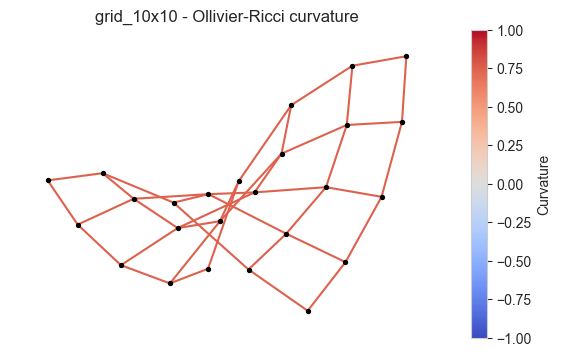

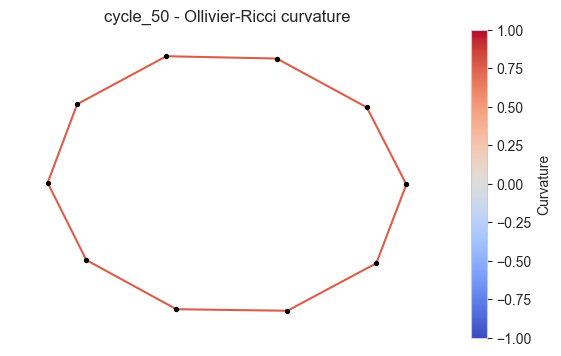

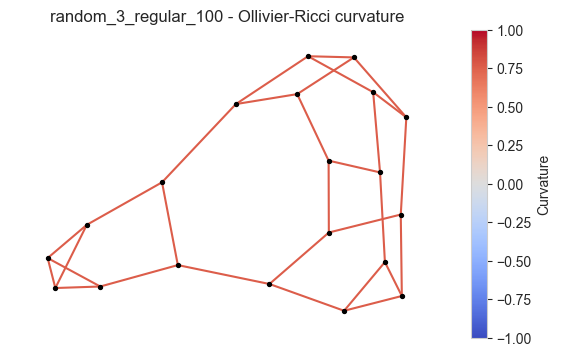

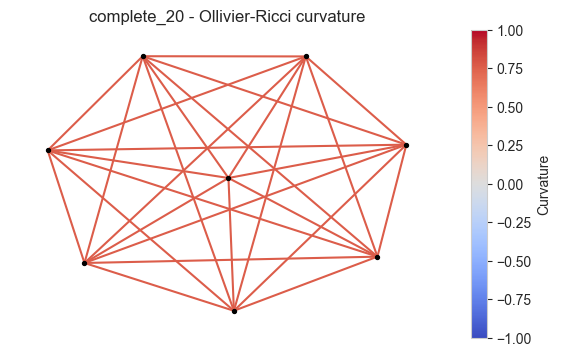

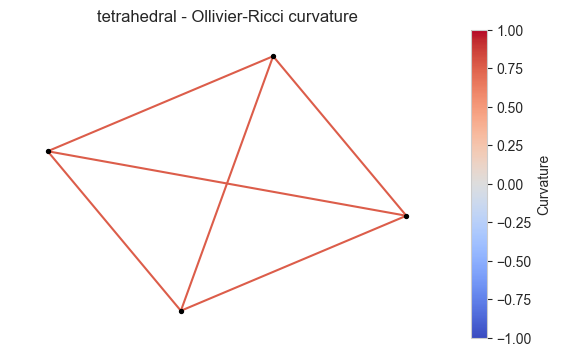

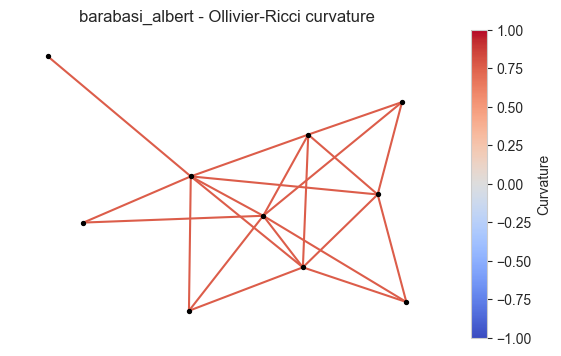

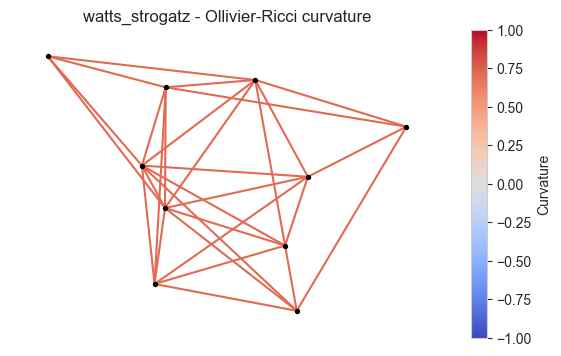

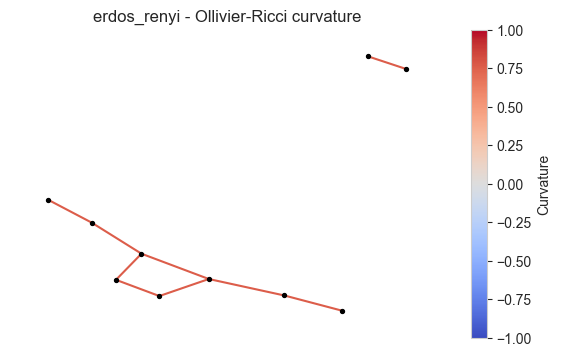

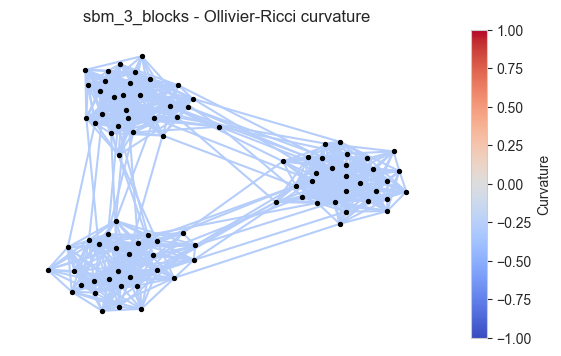

In [14]:
# plot every graph in results
for name, curvature_dict in results.items():
    plot_curvature_result(
        graphs[name],
        curvature_dict,
        title=f"{name} - Ollivier-Ricci curvature",
    )

As one can clearly see by the plottings, the curvature implied by the OllivierRicci class does not make any sense. We will therefore try to use anotehr implementation, either ours or previously developed

## 5. Study new curvature implementation

In [15]:
# GraphRicciCurvature configuration for the toy graphs above.
# For these small/medium graphs, exact OTD is usually preferable to Sinkhorn.
GRAPH_RICCI_ALPHA_ARRAY = (0.0, 0.5, 0.999)
GRAPH_RICCI_METHOD = "OTD"
GRAPH_RICCI_WEIGHT = "weight"
GRAPH_RICCI_PROC = 1
GRAPH_RICCI_SHORTEST_PATH = "all_pairs"
GRAPH_RICCI_VERBOSE = "ERROR"

In [16]:
def prepare_graph_for_graph_ricci(G, weight=GRAPH_RICCI_WEIGHT, default_weight=1.0):
    """Return an integer-labelled simple graph with positive distance weights."""
    H = nx.Graph(G)
    H = nx.convert_node_labels_to_integers(H, label_attribute="original_label")
    H.remove_edges_from(nx.selfloop_edges(H))

    for _, _, data in H.edges(data=True):
        edge_weight = data.get(weight, default_weight)
        try:
            edge_weight = float(edge_weight)
        except (TypeError, ValueError):
            edge_weight = default_weight

        if not np.isfinite(edge_weight) or edge_weight <= 0:
            edge_weight = default_weight

        data[weight] = edge_weight

    return H


def edge_curvature_dict(G, curvature_attribute="ricciCurvature"):
    return {
        tuple(sorted((u, v))): float(data[curvature_attribute])
        for u, v, data in G.edges(data=True)
        if curvature_attribute in data
    }


def node_curvature_dict(G, curvature_attribute="ricciCurvature"):
    return {
        node: float(data[curvature_attribute])
        for node, data in G.nodes(data=True)
        if curvature_attribute in data
    }

In [ ]:
def compute_graph_ollivier_ricci(
    G,
    alpha,
    method=GRAPH_RICCI_METHOD,
    weight=GRAPH_RICCI_WEIGHT,
    proc=GRAPH_RICCI_PROC,
    shortest_path=GRAPH_RICCI_SHORTEST_PATH,
    verbose=GRAPH_RICCI_VERBOSE,
):
    H = prepare_graph_for_graph_ricci(G, weight=weight)

    if H.number_of_edges() == 0:
        return {
            "graph": H,
            "edge_curvature": {},
            "node_curvature": {},
            "summary": {
                "nodes": H.number_of_nodes(),
                "edges": 0,
                "components": nx.number_connected_components(H),
                "alpha": alpha,
                "method": method,
                "min": np.nan,
                "mean": np.nan,
                "max": np.nan,
            },
        }

    orc = GraphOllivierRicci(
        G=H,
        weight=weight,
        alpha=alpha,
        method=method,
        proc=proc,
        shortest_path=shortest_path,
        verbose=verbose,
    )
    ricci_graph = orc.compute_ricci_curvature()
    edge_rc = edge_curvature_dict(ricci_graph)
    node_rc = node_curvature_dict(ricci_graph)
    values = np.array(list(edge_rc.values()), dtype=float)

    return {
        "graph": ricci_graph,
        "edge_curvature": edge_rc,
        "node_curvature": node_rc,
        "summary": {
            "nodes": ricci_graph.number_of_nodes(),
            "edges": ricci_graph.number_of_edges(),
            "components": nx.number_connected_components(ricci_graph),
            "alpha": alpha,
            "method": method,
            "min": values.min(),
            "mean": values.mean(),
            "max": values.max(),
        },
    }

: 

In [ ]:
graph_ricci_results = {}
summary_rows = []

for name, graph in graphs.items():
    for alpha in GRAPH_RICCI_ALPHA_ARRAY:
        result = compute_graph_ollivier_ricci(graph, alpha=alpha)
        graph_ricci_results[(name, alpha)] = result
        summary_rows.append({"graph": name, **result["summary"]})

graph_ricci_summary = pd.DataFrame(summary_rows)
display(graph_ricci_summary)

In [ ]:
GRAPH_RICCI_PLOT_ALPHA = 0.0

for name in graphs.keys():
    result = graph_ricci_results[(name, GRAPH_RICCI_PLOT_ALPHA)]
    plot_curvature_result(
        result["graph"],
        result["edge_curvature"],
        title=f"{name} - GraphRicciCurvature alpha={GRAPH_RICCI_PLOT_ALPHA:g}",
    )

In [ ]:
def plot_curvature_graph_histogram(
    G,
    curvature_dict,
    title=None,
    layout_seed=SEED,
    bins=20,
    tanh_scale=False,
):
    H = nx.convert_node_labels_to_integers(G)
    pos = nx.spring_layout(H, seed=layout_seed)
    edges = list(H.edges())
    values = np.array(
        [curvature_dict.get(tuple(sorted((u, v))), 0.0) for u, v in edges],
        dtype=float,
    )
    plot_values = np.tanh(values) if tanh_scale else values

    if len(plot_values) == 0:
        return

    vmax = max(abs(plot_values.min()), abs(plot_values.max()), 1e-12)
    vmin = -vmax

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 3.8),
        gridspec_kw={"width_ratios": [1.2, 1]},
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        node_size=10,
        node_color="black",
        ax=axes[0],
    )
    nx.draw_networkx_edges(
        H,
        pos,
        edgelist=edges,
        edge_color=plot_values,
        edge_cmap=plt.cm.coolwarm,
        edge_vmin=vmin,
        edge_vmax=vmax,
        width=1.6,
        ax=axes[0],
    )
    axes[0].axis("off")
    axes[0].set_title("Graph")

    sns.histplot(plot_values, bins=bins, kde=False, ax=axes[1], color="steelblue")
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].axvline(plot_values.mean(), color="red", linewidth=1.5, linestyle="--")
    axes[1].set_title("Edge curvature")
    axes[1].set_xlabel("tanh(curvature)" if tanh_scale else "curvature")
    axes[1].set_ylabel("edge count")

    fig.suptitle(title or "GraphRicciCurvature")
    fig.tight_layout()
    plt.show()

In [ ]:
for name in graphs.keys():
    result = graph_ricci_results[(name, GRAPH_RICCI_PLOT_ALPHA)]
    plot_curvature_graph_histogram(
        result["graph"],
        result["edge_curvature"],
        title=f"{name} - alpha={GRAPH_RICCI_PLOT_ALPHA:g}",
        bins=20,
        tanh_scale=False,
    )

In [ ]:
# Compare the new library against the previous local implementation for alpha=0.
# Differences are expected because GraphRicciCurvature uses its own transport setup
# and treats edge weights as shortest-path distances.
comparison_rows = []

for name in graphs.keys():
    old_rc = results.get(name, {})
    new_rc = graph_ricci_results[(name, 0.0)]["edge_curvature"]
    shared_edges = sorted(set(old_rc).intersection(new_rc))
    if not shared_edges:
        continue

    deltas = np.array([new_rc[edge] - old_rc[edge] for edge in shared_edges], dtype=float)
    comparison_rows.append({
        "graph": name,
        "shared_edges": len(shared_edges),
        "mean_abs_delta": np.abs(deltas).mean(),
        "max_abs_delta": np.abs(deltas).max(),
        "old_mean": np.mean([old_rc[edge] for edge in shared_edges]),
        "new_mean": np.mean([new_rc[edge] for edge in shared_edges]),
    })

graph_ricci_comparison = pd.DataFrame(comparison_rows)
display(graph_ricci_comparison)

## 5. Study the dataset - feature distribution etc

1. scatter-plot edge-weights/curvatura
2. perchè i weights sono distribuit in questo modo nel grafo
3. tabella a doppia entrata:
- 3 tipi di struttura ie.: node mean degree, numero di nodi etc
- 3 tipi di features ie.: eterofilia, poi noise?

## 6. Try the effective resistance curvature and compare w/ previous class

## Last - Area for stupid tests

In [ ]:
# 1. sum over a d-dimensional tensor w/o dim specification in just a float32
a = torch.rand((4,4))
b = a.sum()
display(b)

tensor(7.4406)